# Import Toolekit

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer


In [38]:
df = pd.read_csv('../assets/unsupervised-clustering-model-comparison/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Preprocessing

In [39]:
df.duplicated(subset=['country']).sum()

np.int64(0)

In [40]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [41]:
df.describe().T[['mean', '50%']]

,mean,50%
child_mort,38.270060,19.30
exports,41.108976,35.00
health,6.815689,6.32
imports,46.890215,43.30
income,17144.688623,9960.00
inflation,7.781832,5.39
life_expec,70.555689,73.10
total_fer,2.947964,2.41
gdpp,12964.155689,4660.00


In [42]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print (f"{col}: {df[col].skew():.4f}")

child_mort: 1.4508
exports: 2.4458
health: 0.7057
imports: 1.9053
income: 2.2315
inflation: 5.1540
life_expec: -0.9710
total_fer: 0.9671
gdpp: 2.2181


In [43]:
cols_Wth_Out_Outliers = ['child_mort', 'exports', 'imports', 'inflation', 'income', 'gdpp']

for col in cols_Wth_Out_Outliers:
    df[col] =np.log1p(df[col])

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [44]:
df.describe().T[['mean', '50%']]

,mean,50%
child_mort,3.127734,3.010621
exports,3.553176,3.583519
health,6.815689,6.320000
imports,3.746839,3.790985
income,9.115631,9.206433
inflation,1.753665,1.864080
life_expec,70.555689,73.100000
total_fer,2.947964,2.410000
gdpp,8.500171,8.446985


In [45]:
scaler = StandardScaler()

for col in numeric_cols:
    df[col] = scaler.fit_transform(df[[col]])

In [46]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,1.278012,-1.764313,0.279088,0.147868,-1.413035,0.565707,-1.619092,1.902882,-1.460301
1,Albania,-0.239708,-0.283872,-0.097016,0.291835,0.071660,-0.048485,0.647866,-0.859973,-0.122835
2,Algeria,0.198464,0.184161,-0.966073,-0.498946,0.285240,1.037243,0.670423,-0.038404,-0.064916
3,Angola,1.531191,0.908223,-1.448071,0.065136,-0.353257,1.336981,-1.179234,2.128151,-0.221309
4,Antigua and Barbuda,-0.648481,0.437193,-0.286894,0.642228,0.605586,-0.823427,0.704258,-0.541946,0.608135


In [47]:
x = df.drop('country', axis=1)
x.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.278012,-1.764313,0.279088,0.147868,-1.413035,0.565707,-1.619092,1.902882,-1.460301
1,-0.239708,-0.283872,-0.097016,0.291835,0.071660,-0.048485,0.647866,-0.859973,-0.122835
2,0.198464,0.184161,-0.966073,-0.498946,0.285240,1.037243,0.670423,-0.038404,-0.064916
3,1.531191,0.908223,-1.448071,0.065136,-0.353257,1.336981,-1.179234,2.128151,-0.221309
4,-0.648481,0.437193,-0.286894,0.642228,0.605586,-0.823427,0.704258,-0.541946,0.608135


In [48]:
x.isna().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     4
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [55]:
df.dropna(inplace=True)

In [56]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [58]:
x = df.drop('country', axis=1)
x.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.278012,-1.764313,0.279088,0.147868,-1.413035,0.565707,-1.619092,1.902882,-1.460301
1,-0.239708,-0.283872,-0.097016,0.291835,0.071660,-0.048485,0.647866,-0.859973,-0.122835
2,0.198464,0.184161,-0.966073,-0.498946,0.285240,1.037243,0.670423,-0.038404,-0.064916
3,1.531191,0.908223,-1.448071,0.065136,-0.353257,1.336981,-1.179234,2.128151,-0.221309
4,-0.648481,0.437193,-0.286894,0.642228,0.605586,-0.823427,0.704258,-0.541946,0.608135


In [59]:
x.shape

(163, 9)

In [61]:
df.shape

(163, 10)

# Traininig 

### Kmeans 

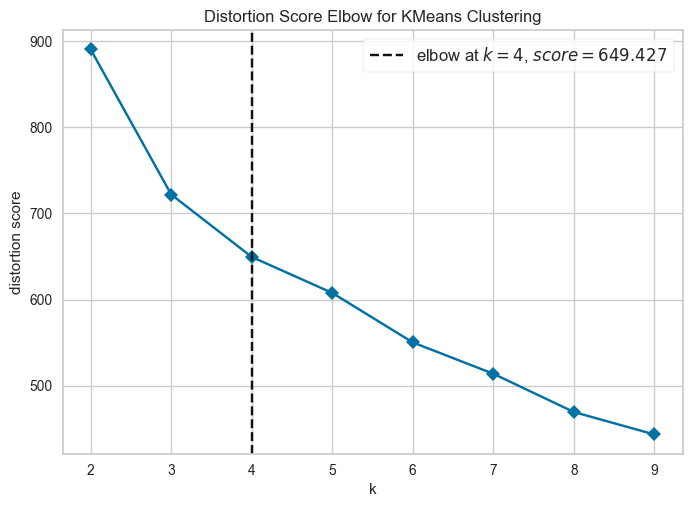

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [67]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10) ,timings=False,  force_model=True)
visualizer.fit(x)
visualizer.show()

In [64]:
model = KMeans(random_state=42, n_clusters=4)
df['cluster'] = model.fit_predict(x)
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,1.278012,-1.764313,0.279088,0.147868,-1.413035,0.565707,-1.619092,1.902882,-1.460301,2
1,Albania,-0.239708,-0.283872,-0.097016,0.291835,0.071660,-0.048485,0.647866,-0.859973,-0.122835,0
2,Algeria,0.198464,0.184161,-0.966073,-0.498946,0.285240,1.037243,0.670423,-0.038404,-0.064916,0
3,Angola,1.531191,0.908223,-1.448071,0.065136,-0.353257,1.336981,-1.179234,2.128151,-0.221309,2
4,Antigua and Barbuda,-0.648481,0.437193,-0.286894,0.642228,0.605586,-0.823427,0.704258,-0.541946,0.608135,1


In [65]:
df['cluster'].value_counts()

cluster
0    67
1    52
2    43
3     1
Name: count, dtype: int64

In [66]:
score = silhouette_score(x, df['cluster'])
print(f"KMeans silhouette score: {score:.4f}")

KMeans silhouette score: 0.2599


### HAC

In [70]:
best_score = -1
best_N = 0

for n_clusters in range(2, 10):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(x)
    score = silhouette_score(x, labels)
    if score > best_score:
        best_score = score
        best_N = n_clusters

print(f"Best AgglomerativeClustering silhouette score: {best_score:.4f} with n_clusters={best_N}")

Best AgglomerativeClustering silhouette score: 0.2627 with n_clusters=2


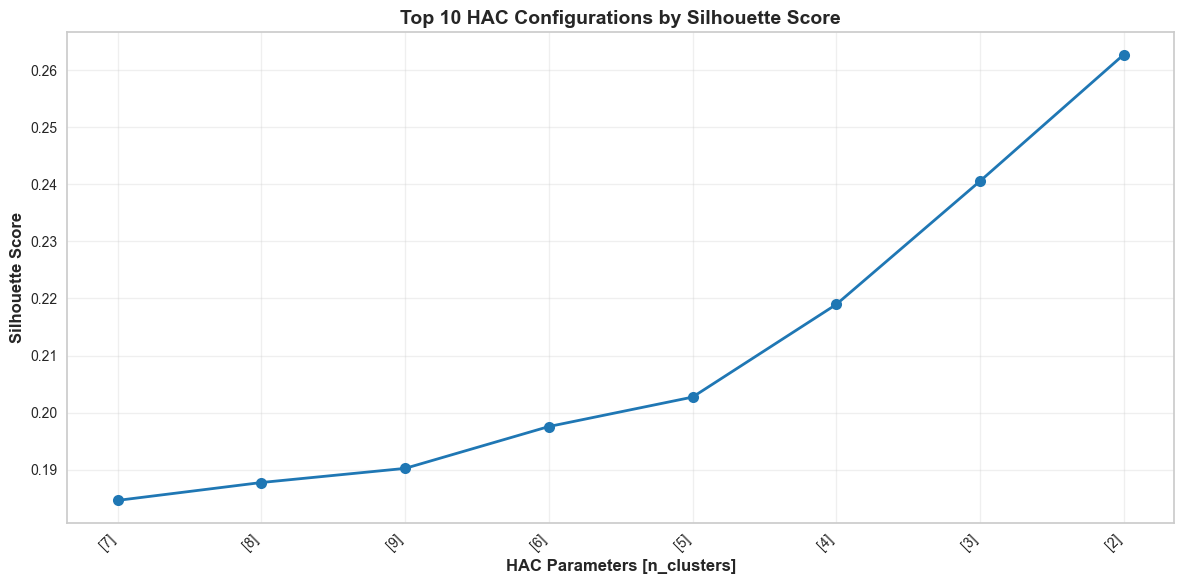

In [87]:

hac_results = []

for n_clusters in range(2, 10):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(x)
    score = silhouette_score(x, labels)
    hac_results.append((n_clusters, score))


hac_top_10 = sorted(hac_results, key=lambda x: x[1], reverse=True)[:10]


hac_x_labels = [f"[{n_clusters}]" for n_clusters, _ in hac_top_10[::-1]]
hac_silhouette_scores = [score for _, score in hac_top_10[::-1]]

plt.figure(figsize=(12, 6))
plt.plot(range(len(hac_silhouette_scores)), hac_silhouette_scores, marker='o', linewidth=2, markersize=8, color='#1f77b4')
plt.xticks(range(len(hac_x_labels)), hac_x_labels, rotation=45, ha='right')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.xlabel('HAC Parameters [n_clusters]', fontsize=12, fontweight='bold')
plt.title('Top 10 HAC Configurations by Silhouette Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### DBSCAN

In [68]:
eps_values = np.arange(0.1, 1.5, 0.1)
min_samples_values = np.arange(3, 10)

best_score = -1
best_Parameters = ()

for eps in eps_values:
    for min_samples in min_samples_values:
        
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(x)
        if len(set(labels[labels != -1])) > 1:
            score = silhouette_score(x[labels != -1], labels[labels != -1])
            if score > best_score:
                best_score = score
                best_Parameters = (eps, min_samples)

print(f"Best DBSCAN silhouette score: {best_score:.4f} with eps={best_Parameters[0]:.1f} and min_samples={best_Parameters[1]}")

Best DBSCAN silhouette score: 0.5155 with eps=1.0 and min_samples=5


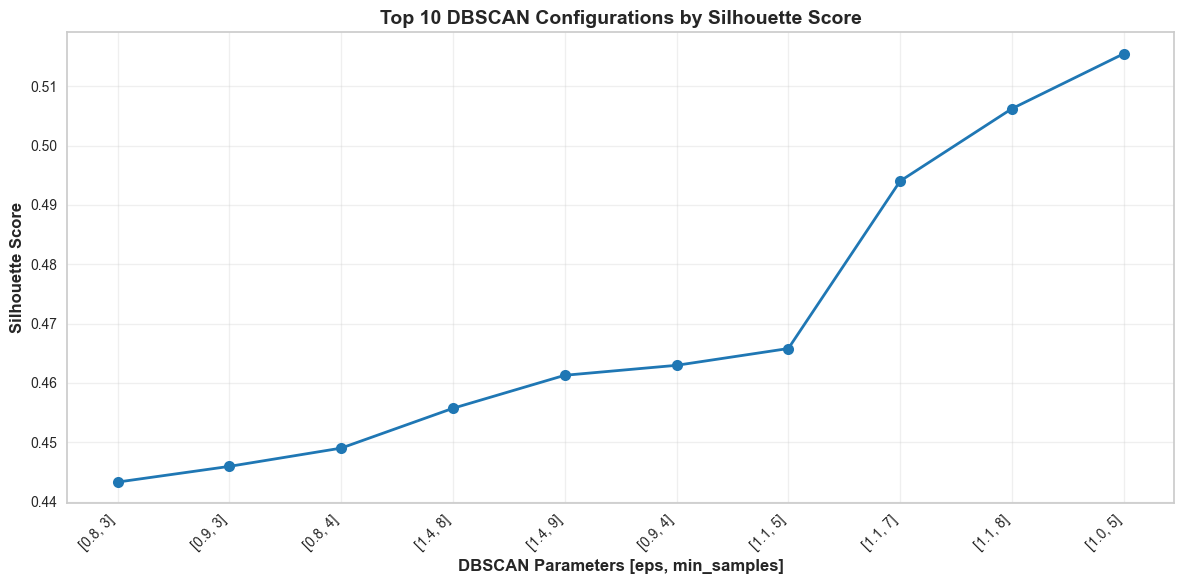

In [88]:
dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(x)
        if len(set(labels[labels != -1])) > 1:
            score = silhouette_score(x[labels != -1], labels[labels != -1])
            dbscan_results.append((eps, min_samples, score))


dbscan_top_10 = sorted(dbscan_results, key=lambda x: x[2], reverse=True)[:10]


dbscan_x_labels = [f"[{eps:.1f}, {min_samples}]" for eps, min_samples, _ in dbscan_top_10[::-1]]
dbscan_silhouette_scores = [score for _, _, score in dbscan_top_10[::-1]]

plt.figure(figsize=(12, 6))
plt.plot(range(len(dbscan_silhouette_scores)), dbscan_silhouette_scores, marker='o', linewidth=2, markersize=8, color='#1f77b4')
plt.xticks(range(len(dbscan_x_labels)), dbscan_x_labels, rotation=45, ha='right')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.xlabel('DBSCAN Parameters [eps, min_samples]', fontsize=12, fontweight='bold')
plt.title('Top 10 DBSCAN Configurations by Silhouette Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Silhouette Scores for Clustering Algorithms')

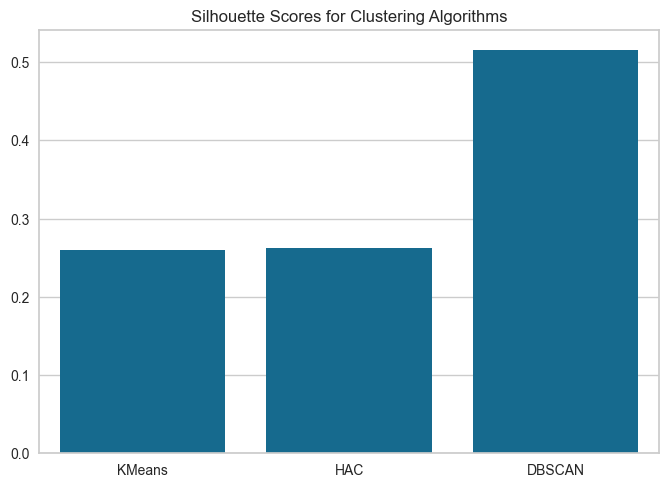

In [74]:
algorithms = ['KMeans', 'HAC','DBSCAN' ]
scores = [0.2599, 0.2627, 0.5155]  

sns.barplot(x=algorithms, y=scores)
plt.title('Silhouette Scores for Clustering Algorithms')
